# ML Foundations — Supervised vs Unsupervised, Train-Test Split, Cross-Validation, Scaling

*Part of the ML Course Reference Series.*

## Q1: What is the difference between supervised and unsupervised learning?

**Supervised** — every training example has a label (target). The model learns to map inputs → outputs.
- Classification: label is a category (spam/not spam)
- Regression: label is a number (house price)

**Unsupervised** — no labels. The model finds structure in the data itself.
- Clustering: group similar examples (K-Means)
- Dimensionality reduction: compress features (PCA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
sns.set_theme(style='whitegrid')
np.random.seed(42)
from sklearn.datasets import load_iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
from sklearn.datasets import load_breast_cancer
_cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = _cancer.data, _cancer.target


In [2]:
from sklearn.cluster import KMeans

# --- Supervised: predict iris species (label exists) ---
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_iris, y_iris)
print('Supervised accuracy:', round(clf.score(X_iris, y_iris), 3))

# --- Unsupervised: cluster iris without using labels ---
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km.fit(X_iris)
print('Unsupervised cluster labels:', np.unique(km.labels_))

Supervised accuracy: 0.973
Unsupervised cluster labels: [0 1 2]


## Q2: What is train-test split and why do we need it?

We hold out a portion of data the model never sees during training. This gives an honest estimate of how well the model generalises to new data.

Without it, accuracy measured on training data is optimistic — the model may have memorised it.

**`stratify=y`** preserves the class ratio in both splits — always use it for classification.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print('Train size:', X_train.shape[0])
print('Test  size:', X_test.shape[0])

# Class proportions should be roughly equal
print('Train class ratio:', y_train.value_counts(normalize=True).round(2).to_dict())
print('Test  class ratio:', y_test.value_counts(normalize=True).round(2).to_dict())

Train size: 455
Test  size: 114
Train class ratio: {1: 0.63, 0: 0.37}
Test  class ratio: {1: 0.63, 0: 0.37}


## Q3: What is cross-validation and when should you use it?

K-fold CV splits the data into K parts. The model is trained K times — each time one fold is the test set and the rest are training. Final score = mean across K runs.

**Why:** A single train-test split can be lucky or unlucky depending on which samples land where. CV gives a more stable, less variance-prone estimate.

**When:** Use CV for model selection and hyperparameter tuning. Use a held-out test set only for final evaluation.

CV scores per fold: [0.912 0.895 0.939 0.956 0.894]
Mean: 0.919  Std: 0.025


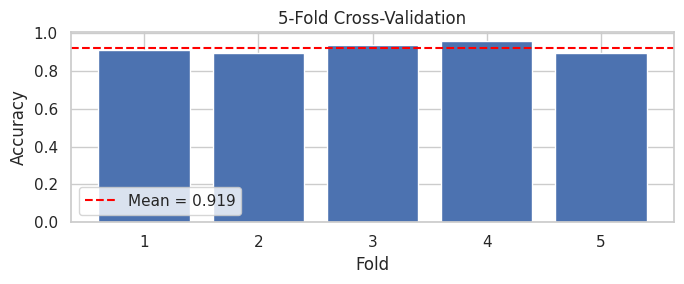

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
scores = cross_val_score(clf, X_cancer, y_cancer, cv=5, scoring='accuracy')

print('CV scores per fold:', scores.round(3))
print(f'Mean: {scores.mean():.3f}  Std: {scores.std():.3f}')

# Visualise fold-by-fold variance
plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), scores)
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

## Q3b: What does a typical ML project pipeline look like?

```
Raw data
   │
   ▼
1. EDA  ──────────────── understand distributions, missing values, correlations
   │
   ▼
2. Feature Engineering ─ create/transform features (log, ratios, binning)
   │
   ▼
3. Preprocessing ──────── impute → scale → encode (inside a Pipeline!)
   │
   ▼
4. Model Selection ─────── try several algorithms with cross-validation
   │
   ▼
5. Hyperparameter Tuning ─ GridSearchCV / RandomizedSearchCV
   │
   ▼
6. Final Evaluation ─────── run once on the held-out test set, report metrics
   │
   ▼
7. Deployment ────────────── serialize pipeline (joblib), serve predictions
```

**Golden rule:** the test set is touched **exactly once** — at the very end.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib, tempfile, os

# ── Step 1: Load & EDA ───────────────────────────────────────────────────────
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')
print(f'Missing values: {X.isnull().sum().sum()}')

# ── Step 2: Train-test split (done FIRST, before any fitting) ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# ── Step 3: Build pipeline (preprocessing + model) ───────────────────────────
pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# ── Step 4: Model selection via cross-validation ─────────────────────────────
cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
print(f'\nCV F1 (default RF): {cv_score:.4f}')

# ── Step 5: Hyperparameter tuning ────────────────────────────────────────────
param_grid = {'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 5]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.4f}')

# ── Step 6: Final evaluation on test set (only once!) ────────────────────────
y_pred = grid.predict(X_test)
print(f'\nTest set classification report:')
print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))

# ── Step 7: Serialize pipeline ───────────────────────────────────────────────
tmp = tempfile.mktemp(suffix='.pkl')
joblib.dump(grid.best_estimator_, tmp)
loaded_pipe = joblib.load(tmp)
print(f'Serialized and reloaded pipeline predictions match: '
      f'{(loaded_pipe.predict(X_test) == y_pred).all()}')
os.unlink(tmp)


Dataset: 569 samples, 30 features
Class balance: {1: 357, 0: 212}
Missing values: 0



CV F1 (default RF): 0.9634


Best params: {'clf__max_depth': None, 'clf__n_estimators': 100}
Best CV F1:  0.9634

Test set classification report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Serialized and reloaded pipeline predictions match: True


---
# 2. Data Preprocessing

## Q4: How do you handle missing values?

`SimpleImputer` fills missing values with a chosen statistic:
- `'mean'` — good for roughly symmetric numeric columns
- `'median'` — better when the column has outliers
- `'most_frequent'` — for categorical columns
- `'constant'` — fill with a fixed value

Always fit the imputer **only on training data**, then transform both train and test.

In [6]:
from sklearn.impute import SimpleImputer

# Synthetic data with missing values
data = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, np.nan],
    'salary': [50000, 60000, np.nan, 80000, 55000],
    'city':   ['NY', 'LA', np.nan, 'NY', 'LA']
})
print('Before:\n', data)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[['age', 'salary']] = num_imputer.fit_transform(data[['age', 'salary']])
data[['city']] = cat_imputer.fit_transform(data[['city']])

print('\nAfter:\n', data)

Before:
     age   salary city
0  25.0  50000.0   NY
1   NaN  60000.0   LA
2  35.0      NaN  NaN
3  40.0  80000.0   NY
4   NaN  55000.0   LA

After:
     age   salary city
0  25.0  50000.0   NY
1  35.0  60000.0   LA
2  35.0  57500.0   LA
3  40.0  80000.0   NY
4  35.0  55000.0   LA


## Q5: What is the difference between StandardScaler and MinMaxScaler?

| Scaler | Formula | Output range | Use when |
|---|---|---|---|
| `StandardScaler` | `(x - mean) / std` | ~[-3, 3] | Data is roughly normal; algorithms like SVM, KNN |
| `MinMaxScaler` | `(x - min) / (max - min)` | [0, 1] | Neural networks, when bounded range is required |

**Both must be fit on training data only.**  
KNN and SVM are sensitive to scale. Decision Trees and Random Forests are not.

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sample = np.array([[10], [20], [30], [1000]])  # outlier at 1000

std  = StandardScaler().fit_transform(sample)
minmax = MinMaxScaler().fit_transform(sample)

df_cmp = pd.DataFrame({'original': sample.ravel(),
                        'StandardScaler': std.ravel().round(2),
                        'MinMaxScaler': minmax.ravel().round(2)})
print(df_cmp)
# Notice: MinMaxScaler squeezes 10/20/30 near 0 because of the outlier

   original  StandardScaler  MinMaxScaler
0        10           -0.60          0.00
1        20           -0.58          0.01
2        30           -0.55          0.02
3      1000            1.73          1.00


## Q5b: What is normalization and how does it affect ML models?

"Normalization" is an umbrella term for any technique that rescales features. Three common types:

| Technique | Formula | Output | Use when |
|---|---|---|---|
| **Min-Max** | (x − min) / (max − min) | [0, 1] | Neural networks; bounded range needed |
| **Z-score (Standardisation)** | (x − μ) / σ | mean=0, std=1 | KNN, SVM, Logistic Regression |
| **L2 normalisation** | x / \|\|x\|\| | unit norm per sample | Text/NLP, cosine similarity |

**Which algorithms care?**
- **Sensitive:** KNN, SVM, Logistic Regression, Ridge/Lasso, Neural Networks
- **Not sensitive:** Decision Tree, Random Forest, Gradient Boosting — they use thresholds, not distances

**Always fit on train, transform both.** A `Pipeline` does this automatically.

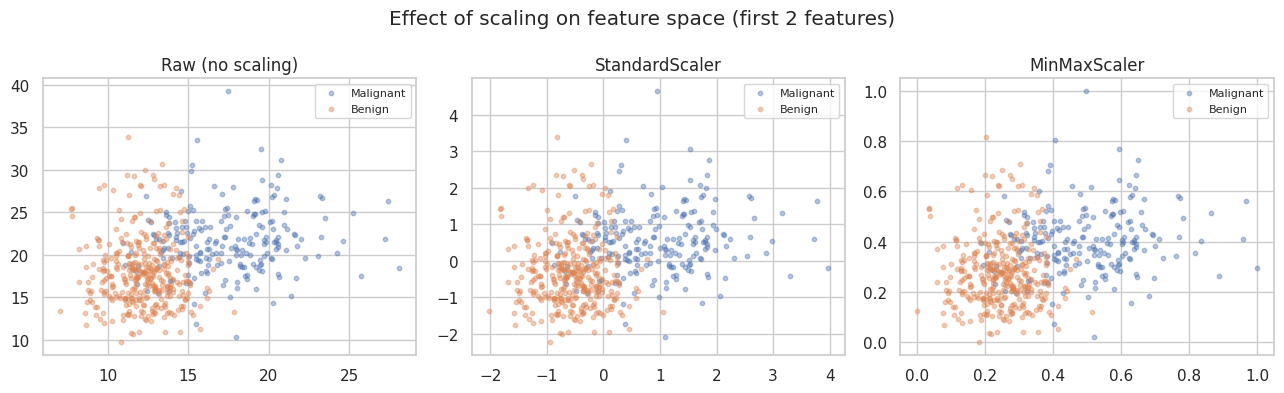

KNN CV accuracy by scaling:
  No scaling     : 0.9262
  StandardScaler : 0.9701
  MinMaxScaler   : 0.9701


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

# Visual: effect of scaling on two features with very different ranges
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ['Raw (no scaling)', 'StandardScaler', 'MinMaxScaler']
datasets = [X[:, :2],
            StandardScaler().fit_transform(X[:, :2]),
            MinMaxScaler().fit_transform(X[:, :2])]

for ax, Xs, label in zip(axes, datasets, labels):
    ax.scatter(Xs[y==0, 0], Xs[y==0, 1], alpha=0.4, s=10, label='Malignant')
    ax.scatter(Xs[y==1, 0], Xs[y==1, 1], alpha=0.4, s=10, label='Benign')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Effect of scaling on feature space (first 2 features)')
plt.tight_layout()
plt.show()

# Impact on KNN accuracy
print('KNN CV accuracy by scaling:')
for name, scaler in [('No scaling',    None),
                      ('StandardScaler', StandardScaler()),
                      ('MinMaxScaler',   MinMaxScaler())]:
    steps = [('scl', scaler), ('knn', KNeighborsClassifier(n_neighbors=7))] if scaler else             [('knn', KNeighborsClassifier(n_neighbors=7))]
    pipe = Pipeline(steps)
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'  {name:15s}: {score:.4f}')


## Q5c: What is Pearson Correlation and how do you use it in ML?

Pearson's **r** measures the **linear** relationship between two variables.

### Formula

$$r = \frac{\text{cov}(X,\, Y)}{\sigma_X \cdot \sigma_Y}$$

Or equivalently:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

### Interpreting r

| r value | Meaning |
|---|---|
| **+1** | Perfect positive linear relationship |
| **−1** | Perfect negative linear relationship |
| **0** | No *linear* relationship (nonlinear may still exist!) |
| \|r\| > 0.8 | Strong correlation |
| 0.5 < \|r\| ≤ 0.8 | Moderate correlation |
| \|r\| ≤ 0.5 | Weak correlation |

### Uses in ML

1. **Feature selection** — drop one of two features with \|r\| > 0.9 (redundant)
2. **Target correlation** — find which features are most predictive
3. **Multicollinearity detection** — collinear features inflate coefficients in linear models

### Limitations

> Pearson only detects **linear** relationships.  
> Use **Spearman's ρ** for monotonic nonlinear relationships, or **mutual information** for any dependency.


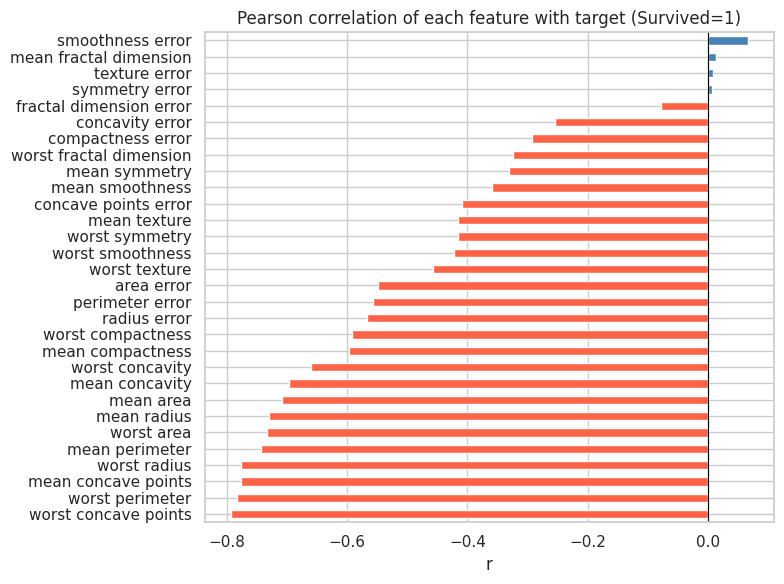

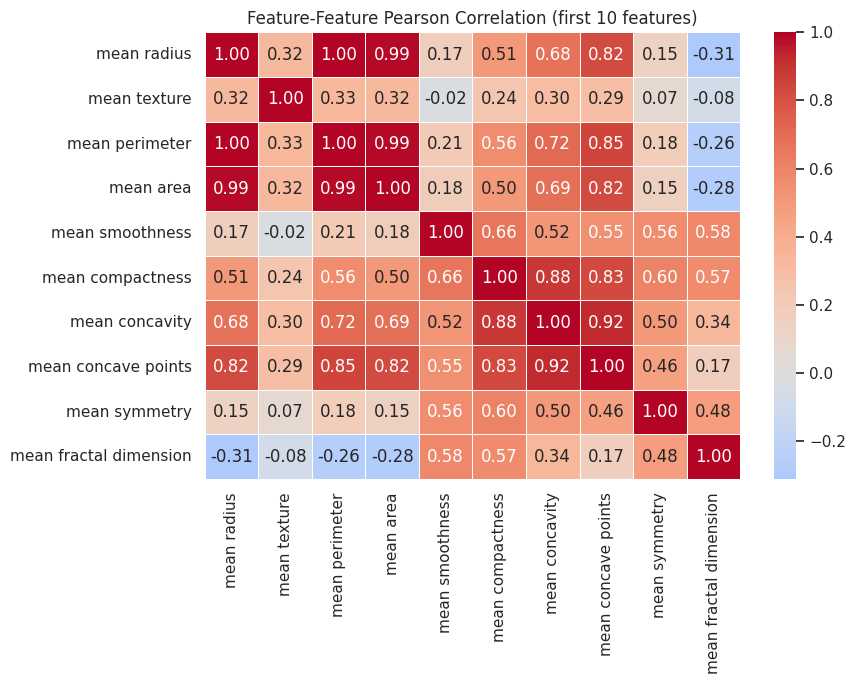

           Pearson r    Spearman rho
Linear              0.9781        0.9783
Nonlinear (exp)     0.9009        0.9916
Spearman handles nonlinear monotonic relationships better


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# ── 1. Correlation with target ────────────────────────────────────────────────
target_corr = X.corrwith(y).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
target_corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in target_corr], ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation of each feature with target (Survived=1)')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

# ── 2. Feature-feature correlation heatmap ───────────────────────────────────
corr_matrix = X.iloc[:, :10].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature-Feature Pearson Correlation (first 10 features)')
plt.tight_layout()
plt.show()

# ── 3. Pearson vs Spearman — nonlinear example ────────────────────────────────
rng = np.random.default_rng(42)
x = rng.uniform(0, 4, 200)
y_lin  = 2*x + rng.normal(0, 0.5, 200)          # linear
y_nonl = np.exp(x) + rng.normal(0, 0.5, 200)    # nonlinear monotonic

print('           Pearson r    Spearman rho')
for label, yv in [('Linear', y_lin), ('Nonlinear (exp)', y_nonl)]:
    pr, _ = pearsonr(x, yv)
    sr, _ = spearmanr(x, yv)
    print(f'{label:18s}  {pr:.4f}        {sr:.4f}')
print('Spearman handles nonlinear monotonic relationships better')
